In [ ]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash

    !pip -q install gymnasium[mujoco]==1.0.0

    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if our machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

bash: ../xvfb: No such file or directory


# HW4: PPO


In this notebook we will be implementing Proximal Policy Optimization algorithm,
scaled up version of which was used to train [OpenAI Five](https://openai.com/blog/openai-five/)
to [win](https://openai.com/blog/how-to-train-your-openai-five/) against the
world champions in Dota 2.
We will be solving a continuous control environment on which it may be easier and faster
to train an agent, however note that PPO here may not be the best algorithm as, for example,
Soft Actor Critic may be more suited
for continuous control environments.

In [ ]:
from tqdm import tqdm

In [ ]:
!pip install gymnasium mujoco

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 59.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 18.6 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym

os.environ["MUJOCO_GL"] = "egl"

ENV_NAME = "HalfCheetah-v5"


def make_env(**kwargs):
    return gym.make(ENV_NAME, **kwargs)


env = make_env(render_mode="rgb_array")
print("Observation space: ", env.observation_space)
print("Action space: ", env.action_space)

Observation space:  Box(-inf, inf, (17,), float64)
Action space:  Box(-1.0, 1.0, (6,), float32)


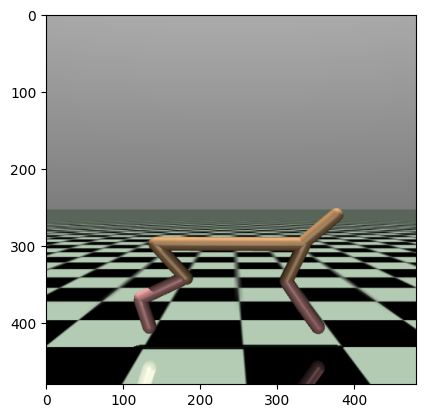

In [ ]:
import matplotlib.pyplot as plt

env.reset()
plt.imshow(env.render())

In [ ]:
from gymnasium.vector import AsyncVectorEnv
from gymnasium.wrappers.vector import (
    NormalizeObservation,
    NormalizeReward,
    ClipReward,
    RecordEpisodeStatistics,
)


def make_vec_env(num_envs, **kwargs):
    """Creates a vectorized Atari environment with preprocessing."""

    # Create a list of environment initialization functions
    env_fns = [lambda: make_env(**kwargs) for i in range(num_envs)]
    envs = AsyncVectorEnv(env_fns, shared_memory=True)
    envs = RecordEpisodeStatistics(envs, buffer_length=100000)

    # Use running statistics to scale observation
    # To have zero mean and unit std
    envs = NormalizeObservation(envs)

    # Use running std to scale reward
    envs = NormalizeReward(envs, gamma=0.99)

    # Clip reward after normalization
    envs = ClipReward(envs, min_reward=-10, max_reward=10)

    return envs


# Parameters
n_envs = 2  # Number of parallel environments
# Create the vectorized environment
vec_env = make_vec_env(n_envs)

In [ ]:
# import tensorflow as tf
import torch

from torch import nn
from torch.nn import functional as F
import torch


class PolicyModel(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.h = 64

        self.action_dim = action_dim
        self.softplus = nn.Softplus()

        self.policy_model = nn.Sequential(
            nn.Linear(state_dim, self.h),
            nn.Tanh(),
            nn.Linear(self.h, self.h),
            nn.Tanh(),
            nn.Linear(self.h, 2 * action_dim),
        )

        self.value_model = nn.Sequential(
            nn.Linear(state_dim, self.h),
            nn.Tanh(),
            nn.Linear(self.h, self.h),
            nn.Tanh(),
            nn.Linear(self.h, 1),
        )


    def get_policy(self, x):
      if not torch.is_tensor(x):
          x = torch.tensor(x, dtype=torch.float32)
      x = x.float()

      out = self.policy_model(x)
      act_dim = out.shape[-1] // 2
      mean, std_raw = out[..., :act_dim], out[..., act_dim:]
      std = torch.nn.functional.softplus(std_raw) + 1e-5
      var = std * std
      return mean, var

    def get_value(self, x):
        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        x = x.float()

        v = self.value_model(x)
        return v.squeeze(-1)

    def forward(self, x):
        policy = self.get_policy(x)
        value = self.get_value(x)

        return policy, value

In [ ]:
from torch.distributions.multivariate_normal import MultivariateNormal


class Policy:
    def __init__(self, model):
        self.model = model

    def act(self, inputs, training=False):
        inputs = torch.tensor(inputs, dtype=torch.float32, device="cuda")

        (mean, var), values = self.model(inputs)
        cov_matrix = torch.diag_embed(var)
        normal_distr = MultivariateNormal(mean, cov_matrix)

        actions = normal_distr.sample()
        log_probs = normal_distr.log_prob(actions)

        if training:
            return {"distribution": normal_distr, "values": values.squeeze()}

        return {
            "actions": actions.cpu().numpy().squeeze(),
            "log_probs": log_probs.detach().cpu().numpy().squeeze(),
            "values": values.detach().cpu().numpy().squeeze(),
        }

In [ ]:
class AsArray:
    """
    Converts lists of interactions to ndarray.
    """

    def __call__(self, trajectory):
        # Modify trajectory inplace.
        for k, v in filter(lambda kv: kv[0] != "state", trajectory.items()):
            trajectory[k] = np.asarray(v)

In [ ]:
""" RL env runner """

from collections import defaultdict

import numpy as np


class EnvRunner:
    """Reinforcement learning runner in an environment with given policy"""

    def __init__(self, env, policy, rollout_length, transforms=None, step_var=None):
        self.env = env
        self.policy = policy
        self.rollout_length = rollout_length
        self.transforms = transforms or []
        self.step_var = step_var if step_var is not None else 0
        self.state = {"latest_observation": self.env.reset()[0]}

    @property
    def num_envs(self):
        """Returns number of batched envs or `None` if env is not batched"""
        return getattr(self.env, "num_envs", None)

    def reset(self, **kwargs):
        """Resets env and runner states."""
        self.state["latest_observation"], info = self.env.reset(**kwargs)
        self.policy.reset()

    def get_next(self):
        """Runs the agent in the environment."""
        trajectory = defaultdict(list, {"actions": []})
        observations = []
        rewards = []
        resets = []
        self.state["env_steps"] = self.rollout_length

        for i in range(self.rollout_length):
            observations.append(self.state["latest_observation"])
            act = self.policy.act(self.state["latest_observation"])
            if "actions" not in act:
                raise ValueError(
                    "result of policy.act must contain 'actions' "
                    f"but has keys {list(act.keys())}"
                )
            for key, val in act.items():
                trajectory[key].append(val)

            obs, rew, terminated, truncated, _ = self.env.step(
                trajectory["actions"][-1]
            )
            done = np.logical_or(terminated, truncated)
            self.state["latest_observation"] = obs
            rewards.append(rew)
            resets.append(done)
            self.step_var += self.num_envs or 1

            # Only reset if the env is not batched. Batched envs should
            # auto-reset.
            if not self.num_envs and np.all(done):
                self.state["env_steps"] = i + 1
                self.state["latest_observation"] = self.env.reset()[0]

        trajectory.update(observations=observations, rewards=rewards, resets=resets)
        trajectory["state"] = self.state

        for transform in self.transforms:
            transform(trajectory)
        return trajectory

In [ ]:
import numpy as np


class DummyPolicy:
    def act(self, inputs, training=False):
        num_envs = inputs.shape[0]
        assert not training
        return {"actions": np.random.randn(num_envs, 6), "values": [np.nan] * num_envs}


runner = EnvRunner(vec_env, DummyPolicy(), 3, transforms=[AsArray()])
trajectory = runner.get_next()

{k: v.shape for k, v in trajectory.items() if k != "state"}

{'actions': (3, 2, 6),
 'values': (3, 2),
 'observations': (3, 2, 17),
 'rewards': (3, 2),
 'resets': (3, 2)}

In [ ]:
class GAE:
    """Generalized Advantage Estimator."""

    def __init__(self, policy, gamma=0.99, lambda_=0.95):
        self.policy = policy
        self.gamma = gamma
        self.lambda_ = lambda_

    def __call__(self, trajectory):
        gamma = self.gamma
        lambda_ = self.lambda_

        rewards = np.asarray(trajectory["rewards"])
        resets  = np.asarray(trajectory["resets"]).astype(np.float32)
        values  = np.asarray(trajectory["values"])

        rewards = np.squeeze(rewards)
        resets  = np.squeeze(resets)
        values  = np.squeeze(values)

        T = rewards.shape[0] if rewards.ndim > 0 else values.shape[0]

        if values.ndim == 2:
            N = values.shape[1]
            if rewards.ndim == 1:
                rewards = rewards.reshape(T, 1)
            if resets.ndim == 1:
                resets = resets.reshape(T, 1)

            if rewards.shape != values.shape:
                raise ValueError(f"Shape mismatch: rewards {rewards.shape}, values {values.shape}")
            if resets.shape != values.shape:
                raise ValueError(f"Shape mismatch: resets {resets.shape}, values {values.shape}")

        elif values.ndim == 1:
            rewards = rewards.reshape(T,)
            resets  = resets.reshape(T,)
        else:
            raise ValueError(f"Unexpected values.ndim={values.ndim}, values.shape={values.shape}")

        last_obs = trajectory["state"]["latest_observation"]
        with torch.no_grad():
            last_val = self.policy.act(last_obs, training=False)["values"]
        last_val = np.asarray(last_val).squeeze()

        if values.ndim == 2:
            last_val = last_val.reshape(values.shape[1],)
            last_val = last_val.reshape(1, values.shape[1])
            next_values = np.concatenate([values[1:], last_val], axis=0)
        else:
            last_val = float(last_val)
            next_values = np.concatenate([values[1:], np.array([last_val])], axis=0)

        not_done = 1.0 - resets
        deltas = rewards + gamma * next_values * not_done - values

        advantages = np.zeros_like(values, dtype=np.float32)

        gae = np.zeros(values.shape[1:], dtype=np.float32) if values.ndim == 2 else 0.0
        for t in reversed(range(T)):
            gae = deltas[t] + gamma * lambda_ * not_done[t] * gae
            advantages[t] = gae

        trajectory["advantages"] = advantages
        trajectory["value_targets"] = advantages + values


**Test GAE**

In [ ]:
!curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/actions.npy
!curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/log_probs.npy
!curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/values.npy
!curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/observations.npy
!curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/rewards.npy
!curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/resets.npy
!curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/state.npy
!curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/advantages.npy
!curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/value_targets.npy
!curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/policy

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 98432  100 98432    0     0   582k      0 --:--:-- --:--:-- --:--:--  586k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  8320  100  8320    0     0  61569      0 --:--:-- --:--:-- --:--:-- 61629
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  8320  100  8320    0     0  58479      0 --:--:-- --:--:-- --:--:-- 58181
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  272k  100  272k    0     0   923k      0 --:--:-- --:--:-- --:--:--  925k
  % Total    % Received % Xferd  Average Speed   Tim

In [ ]:
def test_gae():
    trajectory = {}
    for key in ["actions", "log_probs", "values", "observations", "rewards", "resets"]:
        trajectory[key] = np.load(f"{key}.npy", allow_pickle=True)
    trajectory["state"] = {"latest_observation": np.array([np.load("state.npy")])}

    policy = torch.load(f"policy", weights_only=False)
    policy.model = policy.model.cuda()
    gae_to_test = GAE(policy, gamma=0.99, lambda_=0.95)

    gae_to_test(trajectory)

    for key in ["advantages", "value_targets"]:
        expected = np.load(f"{key}.npy")
        generated = trajectory[key]
        assert np.allclose(expected.ravel(), generated.ravel(), atol=2e-2), key

    print("All passed")


test_gae()

All passed


In [ ]:
def flatten_first_two_dims(arr):
    if arr.ndim == 2:
        return arr.reshape(-1)
    return arr.reshape(arr.shape[0] * arr.shape[1], *arr.shape[2:])


class TrajectorySampler:
    """Samples minibatches from trajectory for a number of epochs."""

    def __init__(self, runner, num_epochs, num_minibatches, transforms=None):
        self.runner = runner
        self.num_epochs = num_epochs
        self.num_minibatches = num_minibatches
        self.transforms = transforms or []
        self.minibatch_count = 0
        self.epoch_count = 0
        self.trajectory = None

    def shuffle_trajectory(self):
        """Shuffles all elements in trajectory.

        Should be called at the beginning of each epoch.
        """
        trajectory_len = len(self.trajectory["observations"])

        permutation = np.random.permutation(trajectory_len)
        for key, value in self.trajectory.items():
            if key != "state":
                self.trajectory[key] = value[permutation]

    def squeeze_trajectory(self):
        for key, value in self.trajectory.items():
            if key != "state":
                self.trajectory[key] = flatten_first_two_dims(value)

    def get_trajectory(self):
        self.trajectory = self.runner.get_next()
        self.squeeze_trajectory()

    def get_next(self):
        """Returns next minibatch."""
        if not self.trajectory:
            self.get_trajectory()

        if self.minibatch_count == self.num_minibatches:
            self.shuffle_trajectory()
            self.minibatch_count = 0
            self.epoch_count += 1

        if self.epoch_count == self.num_epochs:
            self.get_trajectory()
            self.shuffle_trajectory()
            self.minibatch_count = 0
            self.epoch_count = 0

        trajectory_len = self.trajectory["observations"].shape[0]

        batch_size = trajectory_len // self.num_minibatches

        minibatch = {}
        for key, value in self.trajectory.items():
            if key != "state":
                minibatch[key] = value[
                    self.minibatch_count
                    * batch_size : (self.minibatch_count + 1)
                    * batch_size
                ]

        self.minibatch_count += 1

        for transform in self.transforms:
            transform(minibatch)

        return minibatch

In [ ]:
class NormalizeAdvantages:
    """Normalizes advantages to have zero mean and unit std."""

    def __call__(self, trajectory):
        adv = trajectory["advantages"]
        adv = adv.astype(np.float32, copy=False)

        mean = adv.mean()
        std = adv.std()
        trajectory["advantages"] = (adv - mean) / (std + 1e-8)

In [ ]:
def make_ppo_sampler(
    env,
    policy,
    num_runner_steps=2048,
    gamma=0.99,
    lambda_=0.95,
    num_epochs=10,
    num_minibatches=32,
):
    """Creates runner for PPO algorithm."""
    runner_transforms = [AsArray(), GAE(policy, gamma=gamma, lambda_=lambda_)]
    runner = EnvRunner(env, policy, num_runner_steps, transforms=runner_transforms)

    sampler_transforms = [NormalizeAdvantages()]
    sampler = TrajectorySampler(
        runner,
        num_epochs=num_epochs,
        num_minibatches=num_minibatches,
        transforms=sampler_transforms,
    )
    return sampler

In [ ]:
class PPO:
    def __init__(
        self, policy, optimizer, cliprange=0.2, value_loss_coef=0.25, max_grad_norm=0.5
    ):
        self.policy = policy
        self.optimizer = optimizer
        self.cliprange = cliprange
        self.value_loss_coef = value_loss_coef
        # Note that we don't need entropy regularization for this env.
        self.max_grad_norm = max_grad_norm

    def policy_loss(self, trajectory, act):
        """Computes and returns policy loss on a given trajectory."""
        actions = torch.tensor(trajectory["actions"], dtype=torch.float32, device="cuda")
        old_log_probs = torch.tensor(
            trajectory["log_probs"], dtype=torch.float32, device="cuda"
        )
        advantages = torch.tensor(
            trajectory["advantages"], dtype=torch.float32, device="cuda"
        )

        dist = act["distribution"]
        new_log_probs = dist.log_prob(actions)

        ratio = torch.exp(new_log_probs - old_log_probs)
        unclipped = ratio * advantages
        clipped = torch.clamp(ratio, 1.0 - self.cliprange, 1.0 + self.cliprange) * advantages

        loss = -torch.mean(torch.minimum(unclipped, clipped))
        return loss

    def value_loss(self, trajectory, act):
        """Computes and returns value loss on a given trajectory."""
        v_pred = act["values"].float()

        v_old = torch.tensor(trajectory["values"], dtype=torch.float32, device="cuda")
        v_target = torch.tensor(
            trajectory["value_targets"], dtype=torch.float32, device="cuda"
        )

        v_clipped = v_old + torch.clamp(v_pred - v_old, -self.cliprange, self.cliprange)

        l_simple = (v_pred - v_target) ** 2
        l_clipped = (v_clipped - v_target) ** 2

        loss = torch.mean(torch.maximum(l_simple, l_clipped))
        return loss

    def loss(self, trajectory):
        obs = torch.tensor(trajectory["observations"], dtype=torch.float32, device="cuda")
        act = self.policy.act(obs, training=True)

        p_loss = self.policy_loss(trajectory, act)
        v_loss = self.value_loss(trajectory, act)

        total = p_loss + self.value_loss_coef * v_loss
        return total, {"policy_loss": p_loss, "value_loss": v_loss}


    def step(self, trajectory):
        """Computes the loss function and performs a single gradient step."""
        self.optimizer.zero_grad(set_to_none=True)

        total, parts = self.loss(trajectory)
        total.backward()

        torch.nn.utils.clip_grad_norm_(self.policy.model.parameters(), self.max_grad_norm)
        self.optimizer.step()

        out = {k: float(v.detach().cpu().item()) for k, v in parts.items()}
        out["total_loss"] = float(total.detach().cpu().item())
        return out

In [ ]:
state_dim = vec_env.single_observation_space.shape[0]
action_dim = vec_env.single_action_space.shape[0]

model = PolicyModel(state_dim, action_dim)
model = model.cuda()

policy = Policy(model)

num_envs = 2
vec_env = make_vec_env(num_envs=num_envs)
sampler = make_ppo_sampler(vec_env, policy)

optimizer = torch.optim.Adam(policy.model.parameters(), lr=3e-4, eps=1e-5)
n_iter = 50000

lr_mult = lambda epoch: (1 - (epoch / n_iter))
sched = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_mult)

ppo = PPO(policy, optimizer)

In [ ]:
from IPython.display import clear_output
from matplotlib import pyplot as plt

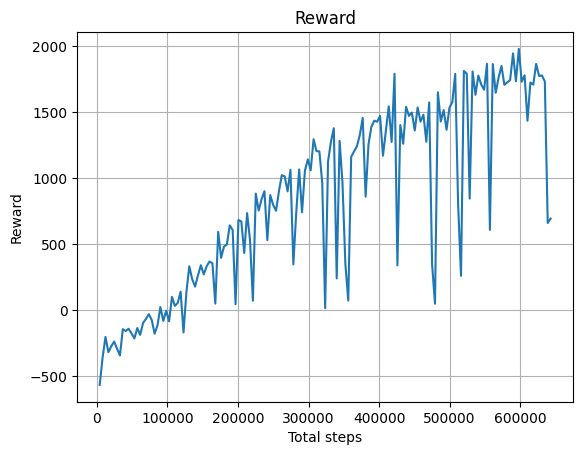

100%|██████████| 50000/50000 [21:05<00:00, 39.52it/s]


In [ ]:
steps = []
rewards = []

for i in tqdm(range(n_iter)):
    trajectory = sampler.get_next()

    if (i + 1) % 100 == 0:
        clear_output(True)
        rewards.append(vec_env.env.env.env.return_queue[-1])
        steps.append(sampler.runner.step_var)

        plt.plot(steps, rewards, label="episode rewards")
        plt.title("Reward")
        plt.xlabel("Total steps")
        plt.ylabel("Reward")
        plt.grid()
        plt.show()

    ppo.step(trajectory)
    sched.step()

## Evaluation

In [ ]:
def evaluate(env, actor, n_games=1, t_max=1000):
    """
    Plays n_games and returns rewards and rendered games
    """
    rewards = []

    for _ in range(n_games):
        s, _ = env.reset()

        R = 0
        for _ in range(t_max):
            # select action for final evaluation of our policy
            action = actor.act(np.array([s]), training=False)["actions"]

            s, r, terminated, truncated, _ = env.step(action)

            R += r

            if terminated or truncated:
                break

        rewards.append(R)
    return np.array(rewards)

In [ ]:
from gymnasium.wrappers import (
    RecordVideo,
    NormalizeObservation as SingleEnvNormalization,
)

# let's hope this will work
# don't forget to pray
test_env = gym.make("HalfCheetah-v5", render_mode="rgb_array")
test_env = SingleEnvNormalization(test_env)
test_env.obs_rms = (
    vec_env.env.env.obs_rms
)  # use the same statistics collected on training
env_monitor = RecordVideo(env=test_env, video_folder="/kaggle/working/videos")
results = evaluate(env_monitor, policy, n_games=5, t_max=1000)

print(results)

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:432: UserWarning: WARN: Unable to save last video! Did you call close()?
  logger.warn("Unable to save last video! Did you call close()?")


[2003.9141207  1994.27426493 1875.87246951 1936.04998404 1595.09688522]


In [ ]:
from pathlib import Path
from base64 import b64encode
from IPython.display import HTML
import sys

video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)

# Bonus area
* Implementing Recurrent PPO using LSTM and comparing it with vanilla MLP PPO. See: https://iclr-blog-track.github.io/2022/03/25/ppo-implementation-details

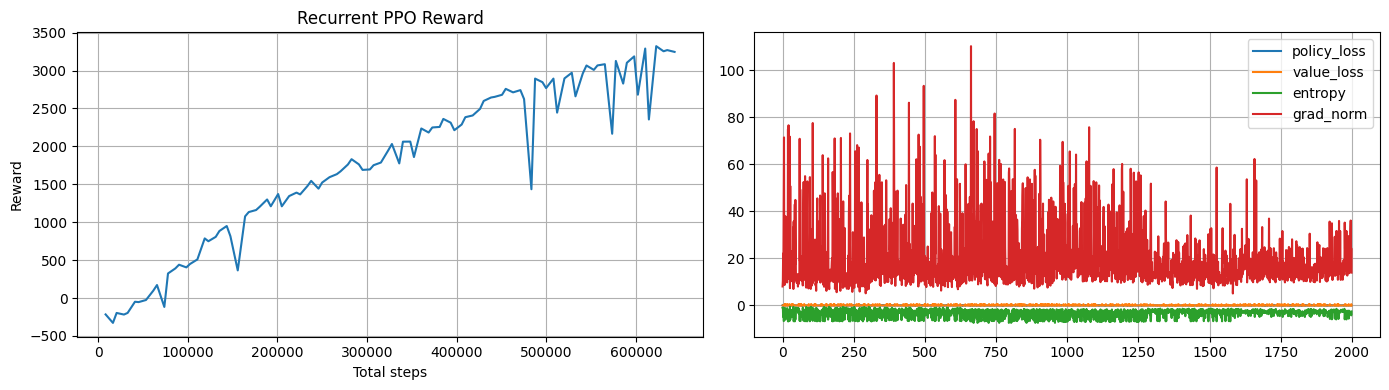

100%|██████████| 50000/50000 [2:06:19<00:00,  6.60it/s]
/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:296: UserWarning: WARN: Overwriting existing videos at /kaggle/working/videos_rppo folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


RPPO results: [3106.9949 2502.07   3188.3833 3336.9844 1599.1967]


In [ ]:
import numpy as np
import torch
import gymnasium as gym
from torch import nn
from torch.distributions import Normal, Independent
from gymnasium.vector import AsyncVectorEnv
from gymnasium.wrappers.vector import NormalizeObservation, NormalizeReward, ClipReward, RecordEpisodeStatistics
from gymnasium.wrappers import RecordVideo, NormalizeObservation as SingleEnvNormalization
from IPython.display import clear_output
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict

torch.backends.cudnn.benchmark = True

# Model
class RecurrentPolicyModel(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_size: int = 128):
        super().__init__()
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.hidden_size = hidden_size

        self.feat = nn.Sequential(
            nn.Linear(state_dim, 64), nn.Tanh(),
            nn.Linear(64, 64),        nn.Tanh(),
        )
        self.lstm_cell = nn.LSTMCell(64, hidden_size)
        self.pi_head   = nn.Linear(hidden_size, 2 * action_dim)
        self.v_head    = nn.Linear(hidden_size, 1)

        nn.init.orthogonal_(self.pi_head.weight, gain=0.01)
        nn.init.orthogonal_(self.v_head.weight,  gain=1.0)

    @torch.jit.export
    def _policy_from_h(self, h: torch.Tensor):
        out  = self.pi_head(h)
        mean = out[..., :self.action_dim]
        std  = torch.nn.functional.softplus(out[..., self.action_dim:]) + 1e-5
        return mean, std

    def forward_step(self, obs: torch.Tensor, hx):
        x       = self.feat(obs)
        h, c    = self.lstm_cell(x, hx)
        mean, std = self._policy_from_h(h)
        v       = self.v_head(h).squeeze(-1)
        return (mean, std), v, (h, c)

    def forward_seq(self, obs_seq: torch.Tensor, resets_seq=None, hx=None):
        B, T, _ = obs_seq.shape
        device   = obs_seq.device

        if hx is None:
            h = obs_seq.new_zeros(B, self.hidden_size)
            c = obs_seq.new_zeros(B, self.hidden_size)
        else:
            h, c = hx

        x_seq = self.feat(obs_seq.view(B * T, -1)).view(B, T, -1)

        means, stds, vals = [], [], []
        for t in range(T):
            if resets_seq is not None and t > 0:
                mask = 1.0 - resets_seq[:, t - 1].unsqueeze(-1)
                h = h * mask
                c = c * mask
            h, c = self.lstm_cell(x_seq[:, t], (h, c))
            mean, std = self._policy_from_h(h)
            means.append(mean)
            stds.append(std)
            vals.append(self.v_head(h))

        mean   = torch.stack(means, dim=1)
        std    = torch.stack(stds,  dim=1)
        values = torch.stack(vals,  dim=1).squeeze(-1)
        return (mean, std), values, (h, c)


# Policy wrapper
class RecurrentPolicy:
    def __init__(self, model: RecurrentPolicyModel, device: str = "cuda"):
        self.model    = model
        self.device   = device
        self.hx       = None
        self.num_envs = None

    def reset(self):
        self.hx       = None
        self.num_envs = None

    def _ensure_hx(self, n: int):
        if self.hx is None or self.num_envs != n:
            self.num_envs = n
            h = torch.zeros(n, self.model.hidden_size, device=self.device)
            c = torch.zeros(n, self.model.hidden_size, device=self.device)
            self.hx = (h, c)

    def act(self, inputs, training: bool = False, resets=None):
        if training:
            obs = torch.as_tensor(inputs, dtype=torch.float32, device=self.device)
            if obs.ndim != 3:
                raise ValueError(f"training=True expects [B,T,obs_dim], got {obs.shape}")
            resets_t = None if resets is None else \
                       torch.as_tensor(resets, dtype=torch.float32, device=self.device)
            (mean, std), values, _ = self.model.forward_seq(obs, resets_seq=resets_t, hx=None)
            dist = Independent(Normal(mean, std), 1)
            return {"distribution": dist, "values": values}

        obs = torch.as_tensor(inputs, dtype=torch.float32, device=self.device)
        if obs.ndim == 1:
            obs = obs.unsqueeze(0)
        n = obs.shape[0]
        self._ensure_hx(n)

        if resets is not None:
            done = torch.as_tensor(resets, dtype=torch.float32, device=self.device).view(n, 1)
            h, c = self.hx
            self.hx = (h * (1.0 - done), c * (1.0 - done))

        with torch.inference_mode():
            (mean, std), values, self.hx = self.model.forward_step(obs, self.hx)
            dist      = Independent(Normal(mean, std), 1)
            actions   = dist.sample()
            log_probs = dist.log_prob(actions)

        return {
            "actions":   actions.cpu().numpy().squeeze(),
            "log_probs": log_probs.cpu().numpy().squeeze(),
            "values":    values.cpu().numpy().squeeze(),
        }


# Transforms / GAE
class AsArray:
    def __call__(self, trajectory):
        for k, v in trajectory.items():
            if k != "state":
                trajectory[k] = np.asarray(v)


class GAE_RNN:
    def __init__(self, policy: RecurrentPolicy, gamma: float = 0.99, lambda_: float = 0.95):
        self.policy  = policy
        self.gamma   = gamma
        self.lambda_ = lambda_

    def __call__(self, trajectory):
        gamma, lam = self.gamma, self.lambda_

        rewards = np.asarray(trajectory["rewards"],  dtype=np.float32)
        resets  = np.asarray(trajectory["resets"],   dtype=np.float32)
        values  = np.asarray(trajectory["values"],   dtype=np.float32)

        rewards = np.squeeze(rewards)
        resets  = np.squeeze(resets)
        values  = np.squeeze(values)

        last_obs = trajectory["state"]["latest_observation"]
        last_val = np.asarray(
            self.policy.act(last_obs, training=False)["values"], dtype=np.float32
        )

        if values.ndim == 1:
            last_val    = float(last_val.squeeze())
            not_done    = 1.0 - resets
            next_values = np.empty_like(values)
            next_values[:-1] = values[1:]
            next_values[-1]  = last_val
            deltas = rewards + gamma * next_values * not_done - values
            adv    = np.empty_like(values)
            gae    = 0.0
            for t in range(len(values) - 1, -1, -1):
                gae    = deltas[t] + gamma * lam * not_done[t] * gae
                adv[t] = gae

        else:
            T, N = values.shape
            rewards = rewards.reshape(T, 1) if rewards.ndim == 1 else rewards
            resets  = resets.reshape(T, 1)  if resets.ndim  == 1 else resets
            last_val = last_val.reshape(1, N)

            not_done    = 1.0 - resets
            next_values = np.empty_like(values)
            next_values[:-1] = values[1:]
            next_values[-1]  = last_val
            deltas = rewards + gamma * next_values * not_done - values
            adv    = np.empty_like(values)
            gae    = np.zeros(N, dtype=np.float32)
            for t in range(T - 1, -1, -1):
                gae    = deltas[t] + gamma * lam * not_done[t] * gae
                adv[t] = gae

        trajectory["advantages"]    = adv
        trajectory["value_targets"] = adv + values


class NormalizeAdvantages:
    def __call__(self, trajectory):
        adv = trajectory["advantages"].astype(np.float32, copy=False)
        trajectory["advantages"] = (adv - adv.mean()) / (adv.std() + 1e-8)


# Environment runner
class EnvRunnerRNN:
    def __init__(self, env, policy: RecurrentPolicy, rollout_length: int,
                 transforms=None, step_var: int = 0):
        self.env            = env
        self.policy         = policy
        self.rollout_length = rollout_length
        self.transforms     = transforms or []
        self.step_var       = step_var
        self.state          = {
            "latest_observation": self.env.reset()[0],
            "latest_reset":       None,
        }

    @property
    def num_envs(self):
        return getattr(self.env, "num_envs", None)

    def reset(self, **kwargs):
        self.state["latest_observation"], _ = self.env.reset(**kwargs)
        self.state["latest_reset"]          = None
        self.policy.reset()

    def get_next(self):
        T  = self.rollout_length
        N  = self.num_envs or 1

        obs_dim    = self.state["latest_observation"].shape[-1]
        act_dim    = self.env.single_action_space.shape[0]

        obs_buf  = np.empty((T, N, obs_dim), dtype=np.float32)
        act_buf  = np.empty((T, N, act_dim), dtype=np.float32)
        lp_buf   = np.empty((T, N),          dtype=np.float32)
        val_buf  = np.empty((T, N),          dtype=np.float32)
        rew_buf  = np.empty((T, N),          dtype=np.float32)
        rst_buf  = np.empty((T, N),          dtype=np.float32)

        self.state["env_steps"] = T

        for i in range(T):
            cur_obs = self.state["latest_observation"]
            cur_rst = self.state["latest_reset"]

            obs_buf[i] = cur_obs

            act_out    = self.policy.act(cur_obs, training=False, resets=cur_rst)
            act_buf[i] = act_out["actions"].reshape(N, act_dim)
            lp_buf[i]  = act_out["log_probs"].reshape(N)
            val_buf[i] = act_out["values"].reshape(N)

            obs, rew, terminated, truncated, _ = self.env.step(act_buf[i].squeeze() if N == 1 else act_buf[i])
            done = np.logical_or(terminated, truncated).astype(np.float32)

            rew_buf[i] = np.asarray(rew,  dtype=np.float32).reshape(N)
            rst_buf[i] = done.reshape(N)

            self.state["latest_observation"] = obs
            self.state["latest_reset"]       = done
            self.step_var += N

            if N == 1 and done.all():
                self.state["env_steps"]          = i + 1
                self.state["latest_observation"] = self.env.reset()[0]
                self.state["latest_reset"]       = None

        trajectory = {
            "observations":  obs_buf,
            "actions":       act_buf,
            "log_probs":     lp_buf,
            "values":        val_buf,
            "rewards":       rew_buf,
            "resets":        rst_buf,
            "state":         self.state,
        }
        for transform in self.transforms:
            transform(trajectory)
        return trajectory


# Minibatch sampler
class RecurrentTrajectorySampler:
    def __init__(self, runner: EnvRunnerRNN, num_epochs: int, num_minibatches: int,
                 seq_len: int = 128, transforms=None):
        self.runner           = runner
        self.num_epochs       = num_epochs
        self.num_minibatches  = num_minibatches
        self.seq_len          = seq_len
        self.transforms       = transforms or []
        self.epoch            = 0
        self.mb               = 0
        self.traj             = None
        self.index            = None

    def _prep(self):
        self.traj = self.runner.get_next()

        if self.traj["observations"].ndim == 2:
            for k, v in self.traj.items():
                if k != "state" and isinstance(v, np.ndarray):
                    self.traj[k] = v[:, np.newaxis, ...] if v.ndim >= 2 else v[:, np.newaxis]

        T, N = self.traj["observations"].shape[:2]
        starts = np.arange(0, T - self.seq_len + 1, self.seq_len, dtype=np.int32)
        env_ids = np.arange(N, dtype=np.int32)
        env_grid, start_grid = np.meshgrid(env_ids, starts, indexing="ij")
        self.index = np.stack([env_grid.ravel(), start_grid.ravel()], axis=1)
        np.random.shuffle(self.index)

        self.epoch = 0
        self.mb    = 0

    def get_next(self):
        if self.traj is None:
            self._prep()

        if self.mb == self.num_minibatches:
            self.mb = 0
            self.epoch += 1
            np.random.shuffle(self.index)

        if self.epoch == self.num_epochs:
            self._prep()

        total_chunks   = len(self.index)
        chunks_per_mb  = max(1, total_chunks // self.num_minibatches)
        start          = self.mb * chunks_per_mb
        end            = total_chunks if self.mb == self.num_minibatches - 1 \
                         else start + chunks_per_mb
        pairs          = self.index[start:end]
        self.mb       += 1

        env_idx  = pairs[:, 0]
        start_idx = pairs[:, 1]
        time_idx = start_idx[:, None] + np.arange(self.seq_len)[None, :]

        def _gather(key):
            return self.traj[key][time_idx, env_idx]

        mbatch = {k: _gather(k) for k in
                  ("observations", "actions", "log_probs", "advantages",
                   "values", "value_targets", "resets")}

        for tr in self.transforms:
            tr(mbatch)
        return mbatch


# PPO loss + update
class PPORecurrent:
    def __init__(self, policy: RecurrentPolicy, optimizer: torch.optim.Optimizer,
                 cliprange: float = 0.2, value_loss_coef: float = 0.25,
                 max_grad_norm: float = 0.5):
        self.policy          = policy
        self.optimizer       = optimizer
        self.cliprange       = cliprange
        self.value_loss_coef = value_loss_coef
        self.max_grad_norm   = max_grad_norm

    def loss(self, traj):
        dev = self.policy.device

        def _t(k, dt=torch.float32):
            return torch.as_tensor(traj[k], dtype=dt, device=dev)

        obs          = _t("observations")
        actions      = _t("actions")
        old_log_probs= _t("log_probs")
        adv          = _t("advantages")
        v_old        = _t("values")
        v_tgt        = _t("value_targets")
        resets       = _t("resets")

        act      = self.policy.act(obs, training=True, resets=resets)
        dist     = act["distribution"]
        v_pred   = act["values"]

        new_log_probs = dist.log_prob(actions)
        ratio         = torch.exp(new_log_probs - old_log_probs)

        policy_loss = -torch.minimum(
            ratio * adv,
            torch.clamp(ratio, 1.0 - self.cliprange, 1.0 + self.cliprange) * adv
        ).mean()

        v_clipped   = v_old + torch.clamp(v_pred - v_old, -self.cliprange, self.cliprange)
        value_loss  = torch.maximum(
            (v_pred - v_tgt).square(),
            (v_clipped - v_tgt).square()
        ).mean()

        total = policy_loss + self.value_loss_coef * value_loss
        ent   = dist.entropy().mean()
        return total, policy_loss.detach(), value_loss.detach(), ent.detach()

    def step(self, traj):
        self.optimizer.zero_grad(set_to_none=True)
        total, p_loss, v_loss, ent = self.loss(traj)
        total.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(
            self.policy.model.parameters(), self.max_grad_norm
        )
        self.optimizer.step()
        return {
            "total_loss":  float(total.detach()),
            "policy_loss": float(p_loss),
            "value_loss":  float(v_loss),
            "entropy":     float(ent),
            "grad_norm":   float(grad_norm),
        }


# Helpers
def make_vec_env_rnn(ENV_NAME: str = "HalfCheetah-v5", num_envs: int = 2, **kwargs):
    def make_env():
        return gym.make(ENV_NAME, **kwargs)
    envs = AsyncVectorEnv([make_env] * num_envs, shared_memory=True)
    envs = RecordEpisodeStatistics(envs, buffer_length=100_000)
    envs = NormalizeObservation(envs)
    envs = NormalizeReward(envs, gamma=0.99)
    envs = ClipReward(envs, min_reward=-10, max_reward=10)
    return envs


def make_rppo_sampler(env, policy: RecurrentPolicy,
                      num_runner_steps: int = 2048, gamma: float = 0.99,
                      lambda_: float = 0.95, num_epochs: int = 10,
                      num_minibatches: int = 32, seq_len: int = 128):
    runner_transforms = [AsArray(), GAE_RNN(policy, gamma=gamma, lambda_=lambda_)]
    runner  = EnvRunnerRNN(env, policy, num_runner_steps, transforms=runner_transforms)
    sampler = RecurrentTrajectorySampler(
        runner, num_epochs=num_epochs, num_minibatches=num_minibatches,
        seq_len=seq_len, transforms=[NormalizeAdvantages()],
    )
    return sampler


def evaluate(env, actor: RecurrentPolicy, n_games: int = 1, t_max: int = 1000):
    rewards = []
    for _ in range(n_games):
        actor.reset()
        s, _ = env.reset()
        R, done_prev = 0.0, None
        for _ in range(t_max):
            action = actor.act(np.array([s], dtype=np.float32),
                               training=False, resets=done_prev)["actions"]
            s, r, terminated, truncated, _ = env.step(action)
            R   += float(r)
            done = bool(terminated or truncated)
            done_prev = np.array([done], dtype=np.bool_)
            if done:
                break
        rewards.append(R)
    return np.asarray(rewards, dtype=np.float32)


# Training
ENV_NAME = "HalfCheetah-v5"
num_envs = 2

vec_env_rnn = make_vec_env_rnn(ENV_NAME=ENV_NAME, num_envs=num_envs)

state_dim  = vec_env_rnn.single_observation_space.shape[0]
action_dim = vec_env_rnn.single_action_space.shape[0]

rnn_model  = RecurrentPolicyModel(state_dim, action_dim, hidden_size=128).cuda()
rnn_policy = RecurrentPolicy(rnn_model)

sampler_rnn = make_rppo_sampler(
    vec_env_rnn, rnn_policy,
    num_runner_steps=2048,
    num_epochs=10,
    num_minibatches=32,
    seq_len=128,
)

n_iter        = 50_000
optimizer_rnn = torch.optim.Adam(rnn_policy.model.parameters(), lr=3e-4, eps=1e-5)
sched_rnn     = torch.optim.lr_scheduler.LambdaLR(optimizer_rnn, lambda e: 1 - e / n_iter)
ppo_rnn       = PPORecurrent(rnn_policy, optimizer_rnn)

steps, ep_rew = [], []
logs = defaultdict(list)
plot_every = 500

for i in tqdm(range(n_iter)):
    traj = sampler_rnn.get_next()
    out  = ppo_rnn.step(traj)
    sched_rnn.step()

    for k in ("policy_loss", "value_loss", "entropy", "grad_norm"):
        logs[k].append(out[k])

    if (i + 1) % plot_every == 0:
        clear_output(True)
        try:
            ep = vec_env_rnn.env.env.env.return_queue[-1]
        except Exception:
            ep = np.nan

        ep_rew.append(ep)
        steps.append(sampler_rnn.runner.step_var)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
        ax1.plot(steps, ep_rew)
        ax1.set_title("Recurrent PPO Reward")
        ax1.set_xlabel("Total steps")
        ax1.set_ylabel("Reward")
        ax1.grid()

        for k in ("policy_loss", "value_loss", "entropy", "grad_norm"):
            ax2.plot(logs[k][-2000:], label=k)
        ax2.legend(); ax2.grid()
        plt.tight_layout()
        plt.show()

# Evaluation
test_env        = gym.make(ENV_NAME, render_mode="rgb_array")
test_env        = SingleEnvNormalization(test_env)
test_env.obs_rms = vec_env_rnn.env.env.obs_rms
env_monitor     = RecordVideo(env=test_env, video_folder="/kaggle/working/videos_rppo")
results         = evaluate(env_monitor, rnn_policy, n_games=5, t_max=1000)
print("RPPO results:", results)